### Goal: Make plots showing the abundance of phylums/classes across the phase space 

In [1]:
import numpy as np
import pandas as pd

from mgsa.io import pH_sample

### First, given native, perturbed index, find new sample ID
from mgsa.io import pH_soil
soils = ['Soil3', 'Soil5', 'Soil6', 'Soil9', 'Soil11', 'Soil12', 'Soil14', 'Soil15', 'Soil16', 'Soil17']
pH_matrix = np.zeros((10,11))
for i in range(len(pH_matrix)):
    pH_matrix[i] = pH_soil(soils[i])

def samples_16s(nat_idx, pert_idx, time = 'T9', drug = 'None', DATDIR = '../data/16s'):
    """
    samples
    input: native (<= 9) and perturbed (<= 10) index
    output: sample name in 16s convention
            3 sample names (3 replicates)
    """
    if time == 'T9':
        soil = soils[nat_idx]
        pH = pH_matrix[nat_idx, pert_idx]
        metadata = pd.read_csv(f'../data/16s/metadata.tsv', sep='\t')
        if drug == 'None':
            metadata_filtered = metadata[(metadata['Soil'] == soil) & (metadata['Nitrate_input'] == 2) & (metadata['Chloramphenicol'].isna()) & (metadata['pH'].round(3) == pH.round(3)) & (metadata['Time'] == time)]
        elif drug == 'CHL':
            metadata_filtered = metadata[(metadata['Soil'] == soil) & (metadata['Nitrate_input'] == 2) & (metadata['Chloramphenicol'] == 'CHL') & (metadata['pH'].round(3) == pH.round(3)) & (metadata['Time'] == time)]
        return metadata_filtered['SampleID'].values
    
    elif time == 'T0':
        soil = soils[nat_idx]
        pH = pH_matrix[nat_idx, pert_idx]
        metadata = pd.read_csv(f'../data/16s/metadata.tsv', sep='\t')
        metadata_filtered = metadata[(metadata['Soil'] == soil) & (metadata['Nitrate_input'] == 2) & (metadata['Time'] == time)]
        return metadata_filtered['SampleID'].values
    

### Next, we need a script which will collect all of the ASVs which correspond to a certain phylum or class

In [2]:


def find_asvs(name, level):
    asv_taxa = pd.read_csv('../data/16s/asv_taxa.tsv', sep = '\t')
    asv_filtered = asv_taxa[(asv_taxa[level] == name)]
    return asv_filtered['ASV'].values



### Next, for a specified class or phylum, loop over native and perturbed pH and collect abundances

In [7]:
import tqdm

name = 'Firmicutes'
level = 'Phylum'
abundance_matrix_T0 = np.zeros((10, 11))
abundance_matrix_T9 = np.zeros((10, 11))

# Read the structure once
all_columns = pd.read_csv('../data/16s/asv_data.tsv', sep='\t', nrows=0).columns
index_column = all_columns[0]
asv_columns = all_columns[1:]

for native in tqdm.trange(10):
    for pert in tqdm.trange(11):
        abundance_T9 = 0
        abundance_T0 = 0
        samples_T9 = samples_16s(native, pert, time = 'T9')
        samples_T0 = samples_16s(native, pert, time = 'T0')
        ASVs = find_asvs(name, level)
        
        # Filter to existing ASVs
        existing_asvs = [asv for asv in ASVs if asv in asv_columns]
        
        if existing_asvs:
            # Load only specific columns
            columns_to_load = [index_column] + existing_asvs
            abundances = pd.read_csv('../data/16s/asv_data.tsv', sep='\t', 
                                   usecols=columns_to_load,
                                   index_col=0)
            
            sample_length_T9 = len(samples_T9)
            sample_length_T0 = len(samples_T0)
            
            for sample in samples_T9:
                if sample in abundances.index:
                    sample_data = abundances.loc[sample]
                    for ASV in existing_asvs:
                        abundance_T9 += sample_data[ASV] / sample_length_T9
                        
            for sample in samples_T0:
                if sample in abundances.index:
                    sample_data = abundances.loc[sample]
                    for ASV in existing_asvs:
                        abundance_T0 += sample_data[ASV] / sample_length_T0
            
        
        abundance_matrix_T9[native, pert] = abundance_T9
        abundance_matrix_T0[native, pert] = abundance_T0

100%|██████████| 10/10 [03:18<00:00, 19.83s/it]


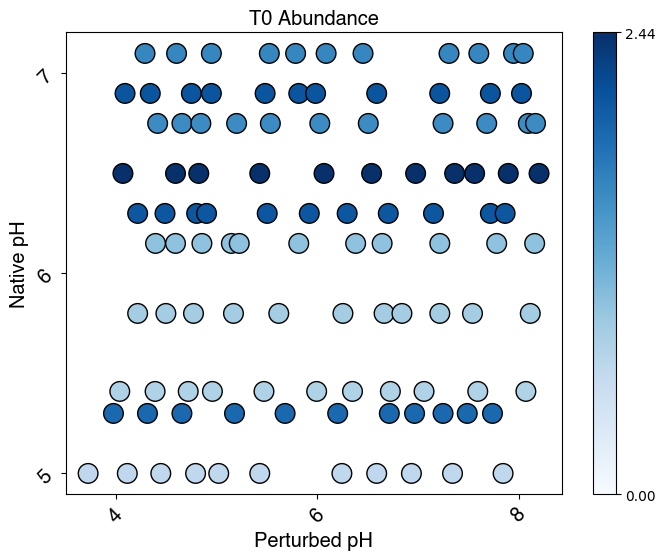

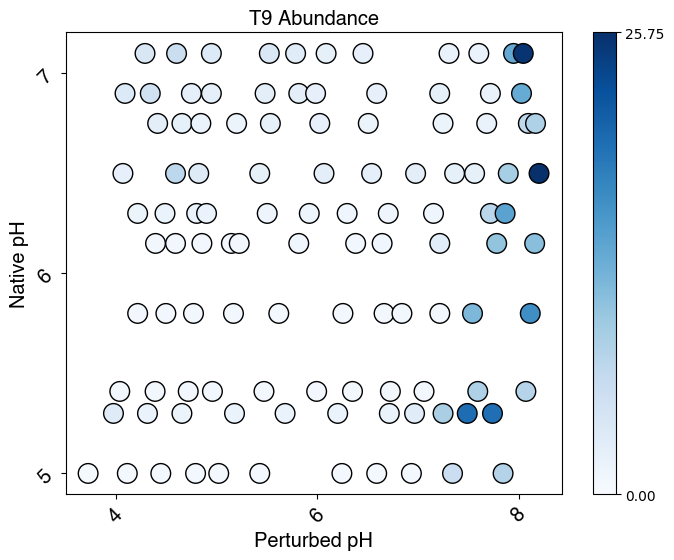

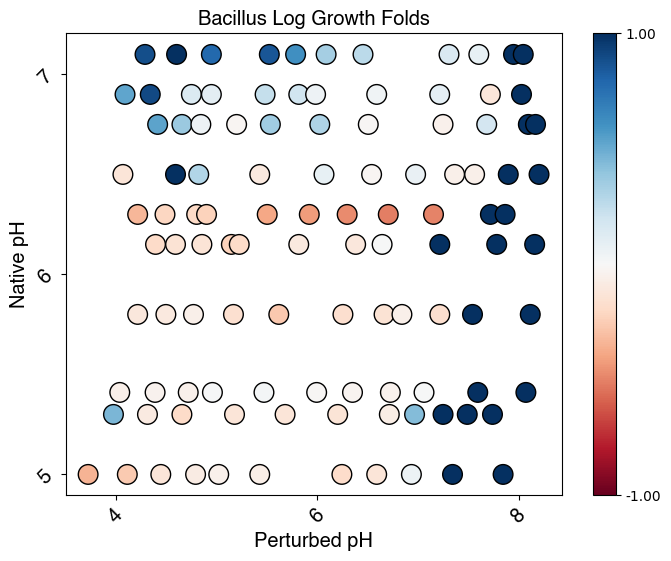

<Axes: title={'center': 'Bacillus Log Growth Folds'}, xlabel='Perturbed pH', ylabel='Native pH'>

In [8]:
from mgsa.helpers import plot
plot(abundance_matrix_T0, 'T0 Abundance', vmin = 0)
plot(abundance_matrix_T9, 'T9 Abundance', vmin = 0)
plot(np.log(abundance_matrix_T9/(abundance_matrix_T0 + 0.0001)), 'Bacillus Log Growth Folds', vmin = -1, vmax = 1, cmap = 'RdBu')



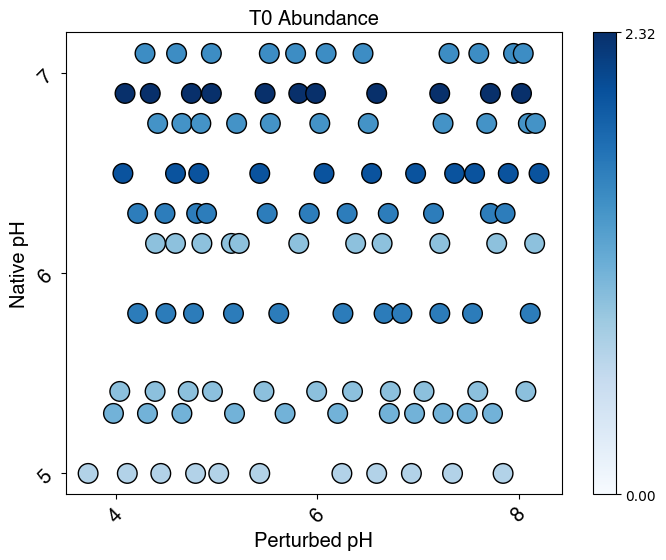

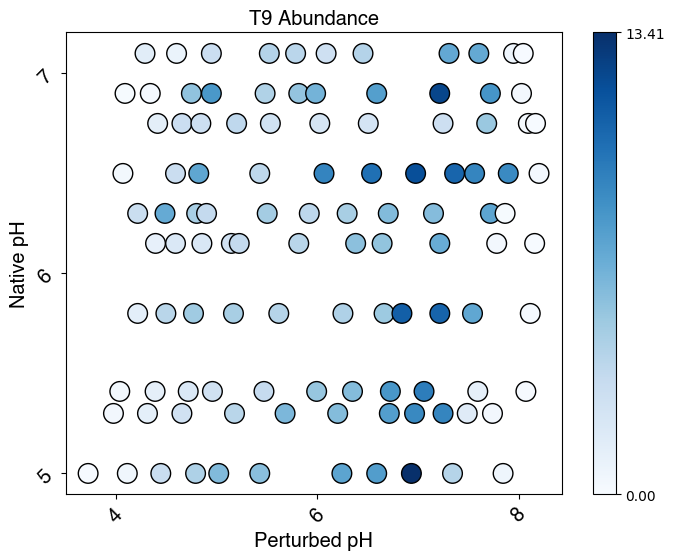

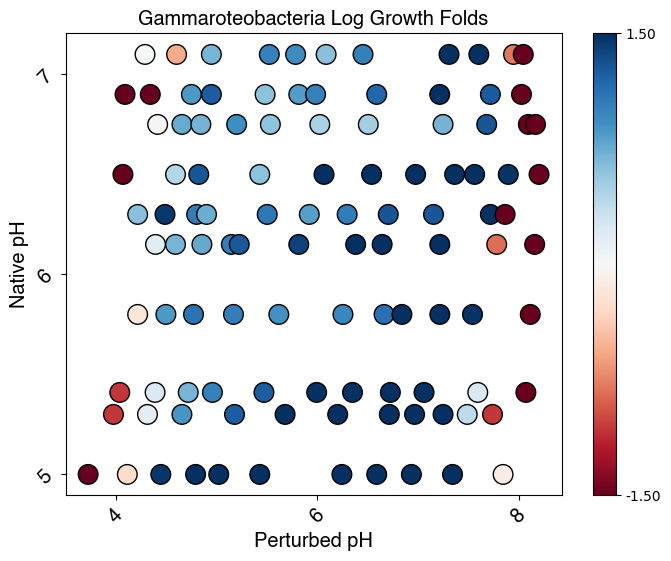

<Axes: title={'center': 'Gammaroteobacteria Log Growth Folds'}, xlabel='Perturbed pH', ylabel='Native pH'>

In [114]:
from mgsa.helpers import plot
plot(abundance_matrix_T0, 'T0 Abundance', vmin = 0)
plot(abundance_matrix_T9, 'T9 Abundance', vmin = 0)
plot(np.log(abundance_matrix_T9/(abundance_matrix_T0 + 0.0001)), 'Gammaroteobacteria Log Growth Folds', vmin = -1.5, vmax = 1.5, cmap = 'RdBu')



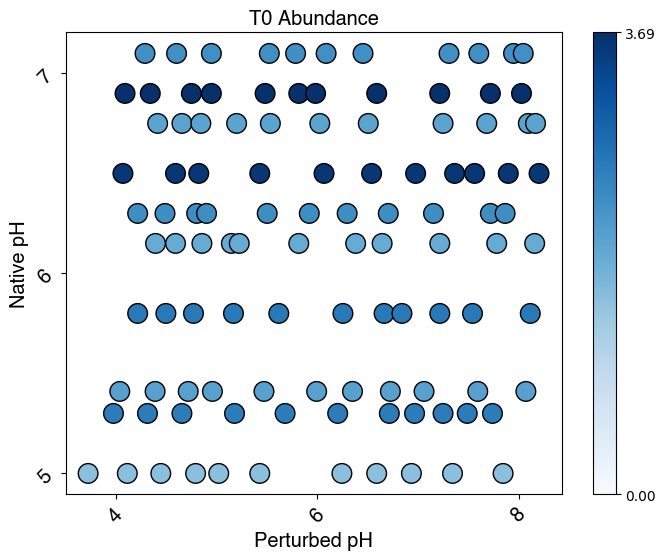

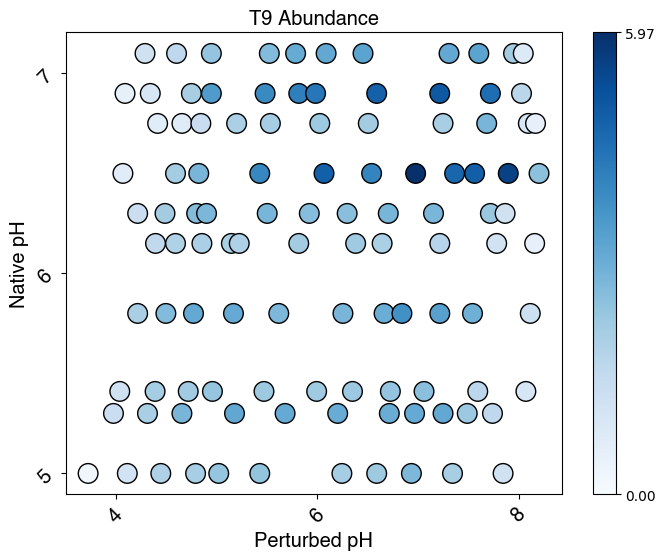

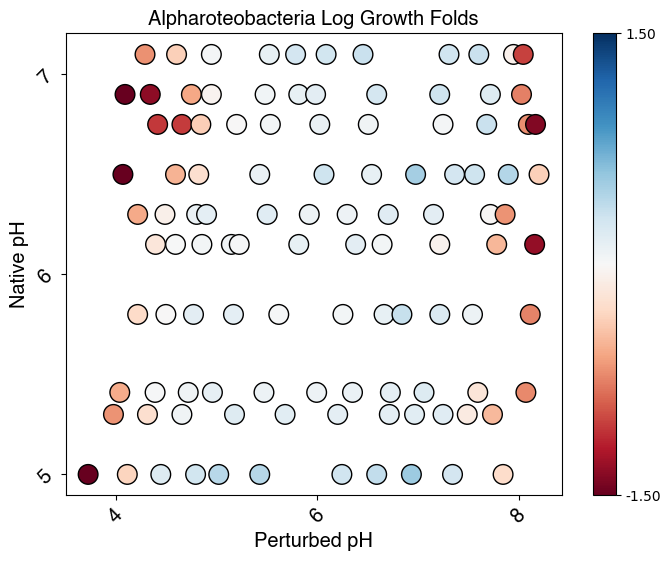

<Axes: title={'center': 'Alpharoteobacteria Log Growth Folds'}, xlabel='Perturbed pH', ylabel='Native pH'>

In [116]:
from mgsa.helpers import plot
plot(abundance_matrix_T0, 'T0 Abundance', vmin = 0)
plot(abundance_matrix_T9, 'T9 Abundance', vmin = 0)
plot(np.log(abundance_matrix_T9/(abundance_matrix_T0 + 0.0001)), 'Alpharoteobacteria Log Growth Folds', vmin = -1.5, vmax = 1.5, cmap = 'RdBu')



In [104]:
taxa = pd.read_csv('../data/16s/asv_taxa.tsv', sep = '\t')

taxa = taxa[(taxa['Order'] == 'Ralstonia')]
print(taxa['Order'].values)


    



[]
